# Positive Semidefinite Matrices

## Motivation

Positive semidefinite (PSD) matrices are the matrix analogue of non-negative real numbers. They arise wherever a notion of "size", "covariance", or "energy" appears — and the geometry of the set of PSD matrices is far richer than scalar non-negativity.

| Domain | PSD Object | Role |
|--------|-----------|------|
| Statistics | Covariance $\Sigma \succeq 0$ | Describes joint distribution of random vectors |
| Kernel methods | Gram matrix $K_{ij} = k(x_i, x_j)$ | Mercer's theorem: valid kernels ↔ PSD matrices |
| Optimization | Hessian $\nabla^2 f \succeq 0$ | Second-order condition for convexity |
| Control | Lyapunov matrix $P \succ 0$ | $V(x) = x^\top P x$ is a valid Lyapunov function |
| Quantum mechanics | Density matrix $\rho \succeq 0$, $\mathrm{tr}(\rho)=1$ | State of a quantum system |
| Semidefinite programming | $X \succeq 0$ (decision variable) | Generalizes linear programming |

## Prerequisites

| Topic | Key Concepts |
|-------|--------------|
| Spectral theorem | Eigendecomposition, symmetric matrices |
| SVD | Singular values, Eckart-Young |
| Matrix functions | $A^{1/2}$, $\log A$, functional calculus |
| Convexity | Convex sets, convex functions |

## References

- Bhatia, *Positive Definite Matrices* (Princeton, 2007) — the definitive reference
- Horn & Johnson, *Matrix Analysis* — Chapter 7
- Boyd & Vandenberghe, *Convex Optimization* — Chapter 2 (PSD cone) and Appendix A
- Vandenberghe & Boyd, "Semidefinite Programming" (SIAM Review, 1996)

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10
RTOL = 1e-6

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

# ── PSD constructors ───────────────────────────────────────────────────────────
def make_pd(n, min_eig=0.5, rng=rng):
    """Random positive definite n×n matrix."""
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lams = min_eig + rng.exponential(1.0, n)
    return Q @ np.diag(lams) @ Q.T

def make_psd_rank_k(n, k, rng=rng):
    """Random PSD matrix of rank k."""
    B = rng.standard_normal((n, k))
    return B @ B.T

print('Setup complete.')

Setup complete.


---
## 1.  Definitions & Characterizations

### 1.1  Definition

A symmetric matrix $A \in \mathbb{R}^{n \times n}$ is **positive semidefinite** ($A \succeq 0$) if:
$$\boxed{x^\top A x \geq 0 \quad \forall\, x \in \mathbb{R}^n}$$

It is **positive definite** ($A \succ 0$) if $x^\top A x > 0$ for all $x \neq 0$.

### 1.2  Equivalent Characterizations

For a symmetric $A$, the following are equivalent:

| Condition | $A \succeq 0$ | $A \succ 0$ |
|-----------|:---:|:---:|
| $x^\top Ax \geq 0$ for all $x$ | ✓ | (strict for $x\neq 0$) |
| All eigenvalues $\lambda_i \geq 0$ | ✓ | All $\lambda_i > 0$ |
| $A = B^\top B$ for some $B$ | ✓ | $B$ has full column rank |
| All leading principal minors $\geq 0$ | ✓ | All $> 0$ (Sylvester's criterion) |
| Cholesky factorization $A = LL^\top$ exists | ✓ (pivoted) | ✓ (unpivoted) |
| $A = A^{1/2} A^{1/2}$ for some PSD $A^{1/2}$ | ✓ | ✓ |

### 1.3  Gram Matrix Construction

Any set of vectors $\{x_1, \ldots, x_n\} \subset \mathbb{R}^d$ defines a **Gram matrix** $G \in \mathbb{R}^{n \times n}$:
$$G_{ij} = \langle x_i, x_j \rangle = x_i^\top x_j$$

Gram matrices are always PSD: for any $c \in \mathbb{R}^n$, $c^\top G c = \|\sum_i c_i x_i\|^2 \geq 0$.

In [2]:
# ── PSD Characterizations ─────────────────────────────────────────────────────

def is_psd(A, tol=1e-10):
    """Check PSD via minimum eigenvalue."""
    return np.min(la.eigh(A, eigvals_only=True)) >= -tol

def is_pd(A, tol=1e-10):
    """Check positive definiteness."""
    return np.min(la.eigh(A, eigvals_only=True)) > tol

def sylvester_criterion(A):
    """Check positive definiteness via Sylvester's criterion (leading principal minors)."""
    n = A.shape[0]
    return all(np.linalg.det(A[:k, :k]) > 0 for k in range(1, n + 1))

def gram_matrix(X):
    """Compute Gram matrix G_ij = <x_i, x_j>.

    Args:
        X: Data matrix, rows are vectors.  Shape: (n, d)

    Returns:
        G: Gram matrix.  Shape: (n, n)
    """
    return X @ X.T

def quadratic_form_psd_check(A, n_trials=500, rng=rng):
    """Monte Carlo check: xᵀAx ≥ 0 for random x."""
    xs = rng.standard_normal((n_trials, A.shape[0]))
    vals = np.einsum('ni,ij,nj->n', xs, A, xs)
    return np.all(vals >= -1e-10), vals.min()


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 5
A_pd  = make_pd(n)
A_psd = make_psd_rank_k(n, k=3)          # rank-3, PSD but not PD
A_indef = rng.standard_normal((n, n))
A_indef = (A_indef + A_indef.T) / 2      # symmetric but indefinite

print('Characterization checks (n=5):')
print('\n  Positive Definite matrix:')
check(is_pd(A_pd),                        'All eigenvalues > 0')
check(sylvester_criterion(A_pd),          "Sylvester's criterion")
ok_pd, min_qf = quadratic_form_psd_check(A_pd)
check(ok_pd,                              f'xᵀAx ≥ 0 for 500 random x  (min = {min_qf:.4f})')

print('\n  PSD rank-3 matrix:')
check(is_psd(A_psd) and not is_pd(A_psd), 'PSD but not PD  (has zero eigenvalue)')
ok_psd, min_psd = quadratic_form_psd_check(A_psd)
check(ok_psd,                             f'xᵀAx ≥ 0 for 500 random x  (min = {min_psd:.6f})')

print('\n  Gram matrix from random data:')
X = rng.standard_normal((8, 3))           # 8 points in R³
G = gram_matrix(X)
check(is_psd(G),                          'Gram matrix is PSD')
check(np.linalg.matrix_rank(G) == 3,      f'rank(G) = 3  (= dim of ambient space)')

print('\n  Indefinite symmetric matrix:')
evals_indef = la.eigh(A_indef, eigvals_only=True)
check(np.any(evals_indef < 0) and np.any(evals_indef > 0),
      f'Has both positive and negative eigenvalues: {np.round(evals_indef, 2)}')

Characterization checks (n=5):

  Positive Definite matrix:
  [PASS]  All eigenvalues > 0
  [PASS]  Sylvester's criterion
  [PASS]  xᵀAx ≥ 0 for 500 random x  (min = 0.2173)

  PSD rank-3 matrix:
  [PASS]  PSD but not PD  (has zero eigenvalue)
  [PASS]  xᵀAx ≥ 0 for 500 random x  (min = 0.033676)

  Gram matrix from random data:
  [PASS]  Gram matrix is PSD
  [PASS]  rank(G) = 3  (= dim of ambient space)

  Indefinite symmetric matrix:
  [PASS]  Has both positive and negative eigenvalues: [-1.14 -0.22  0.52  1.36  2.21]


np.True_

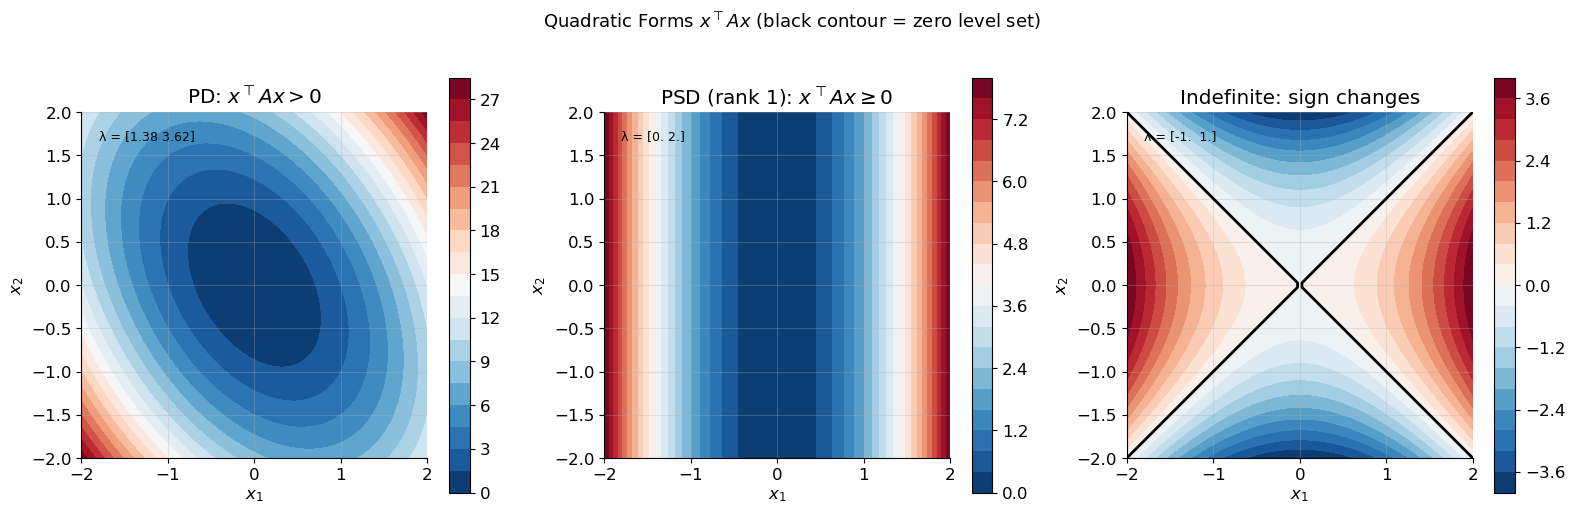

In [3]:
# ── Visualize: Quadratic Forms in 2D ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x_range = np.linspace(-2, 2, 80)
X_grid, Y_grid = np.meshgrid(x_range, x_range)
pts = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)  # (N, 2)

matrices_2d = [
    (np.array([[3., 1.], [1., 2.]]),  'PD: $x^\\top A x > 0$',  PRIMARY),
    (np.array([[2., 0.], [0., 0.]]),  'PSD (rank 1): $x^\\top A x \\geq 0$', TERTIARY),
    (np.array([[1., 0.], [0., -1.]]), 'Indefinite: sign changes', SECONDARY),
]

for ax, (A2, title, cmap_base) in zip(axes, matrices_2d):
    qf = np.einsum('ni,ij,nj->n', pts, A2, pts).reshape(X_grid.shape)
    im = ax.contourf(X_grid, Y_grid, qf, levels=20, cmap='RdBu_r')
    ax.contour(X_grid, Y_grid, qf, levels=[0], colors='k', linewidths=2)
    ax.set_title(title)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
    evals2 = np.round(la.eigh(A2, eigvals_only=True), 2)
    ax.text(0.05, 0.95, f'λ = {evals2}', transform=ax.transAxes,
            fontsize=9, va='top')
    plt.colorbar(im, ax=ax)

plt.suptitle('Quadratic Forms $x^\\top A x$ (black contour = zero level set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2.  The PSD Cone

### 2.1  Convexity

The set $\mathbb{S}^n_+ = \{A \in \mathbb{S}^n : A \succeq 0\}$ of $n \times n$ PSD matrices is a **convex cone** in the vector space $\mathbb{S}^n$ of symmetric matrices:

1. **Cone**: $A \succeq 0, \alpha \geq 0 \Rightarrow \alpha A \succeq 0$
2. **Convex**: $A, B \succeq 0, t \in [0,1] \Rightarrow (1-t)A + tB \succeq 0$
3. **Closed**: If $A_k \succeq 0$ and $A_k \to A$, then $A \succeq 0$
4. **Pointed**: $A \succeq 0$ and $-A \succeq 0 \Rightarrow A = 0$

**Dimension**: $\mathbb{S}^n_+$ lives in $\mathbb{S}^n \cong \mathbb{R}^{n(n+1)/2}$. The interior is $\mathbb{S}^n_{++}$ (positive definite matrices).

### 2.2  Dual Cone

The dual cone of $\mathbb{S}^n_+$ is itself: $\mathbb{S}^n_+$ is **self-dual**:
$$(\mathbb{S}^n_+)^* = \{B \in \mathbb{S}^n : \langle A, B \rangle \geq 0 \; \forall A \succeq 0\} = \mathbb{S}^n_+$$

where $\langle A, B \rangle = \mathrm{tr}(A^\top B) = \mathrm{tr}(AB)$ is the trace inner product.

### 2.3  Extreme Rays

The extreme rays of $\mathbb{S}^n_+$ are the rank-1 matrices $\{vv^\top : v \in \mathbb{R}^n\}$. Every PSD matrix decomposes as a conic combination of rank-1 matrices (outer products of eigenvectors):
$$A = \sum_{i=1}^r \lambda_i q_i q_i^\top \quad (\lambda_i \geq 0)$$

In [4]:
# ── PSD Cone Properties ───────────────────────────────────────────────────────

def psd_cone_check(A, B, t=0.4):
    """Verify cone and convexity properties."""
    results = {}
    # Cone: αA is PSD
    results['cone']    = is_psd(3.0 * A)
    # Convexity: (1-t)A + tB is PSD
    results['convex']  = is_psd((1 - t) * A + t * B)
    # Sum: A + B is PSD
    results['sum']     = is_psd(A + B)
    # Product NOT necessarily PSD (unless they commute)
    results['product'] = is_psd(A @ B)
    return results


def trace_inner_product(A, B):
    """Trace inner product <A, B> = tr(AB)."""
    return np.trace(A @ B)


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 4
A = make_pd(n)
B = make_pd(n)

res = psd_cone_check(A, B)
print('PSD cone properties:')
check(res['cone'],    '3A ≽ 0  (cone: cA ≽ 0 for c ≥ 0)')
check(res['convex'],  '0.6A + 0.4B ≽ 0  (convex combination)')
check(res['sum'],     'A + B ≽ 0  (sum of PSD is PSD)')
print(f'  [INFO] A·B is PSD: {res["product"]}  (NOT guaranteed for non-commuting A, B)')

# Self-duality: tr(AB) ≥ 0 for any A, B ≽ 0
print('\nSelf-duality: tr(AB) ≥ 0 for A, B ≽ 0:')
for _ in range(5):
    Ai = make_psd_rank_k(n, k=rng.integers(1, n+1))
    Bi = make_psd_rank_k(n, k=rng.integers(1, n+1))
    val = trace_inner_product(Ai, Bi)
    assert val >= -1e-10, f'Self-duality violated: tr(AB) = {val:.4f}'
check(True, 'tr(AB) ≥ 0 verified for 5 random PSD pairs')

# Rank-1 decomposition
print('\nRank-1 decomposition A = Σ λᵢ qᵢqᵢᵀ:')
A_test = make_pd(4)
eigvals, Q = la.eigh(A_test)
A_recon = sum(eigvals[i] * np.outer(Q[:,i], Q[:,i]) for i in range(4))
err_recon = np.linalg.norm(A_test - A_recon, 'fro')
check(err_recon < ATOL, f'A = Σ λᵢqᵢqᵢᵀ  (‖err‖_F = {err_recon:.2e})')
check(np.all(eigvals > 0), f'All λᵢ > 0  ({np.round(eigvals, 3)})')

# Visualize 2D PSD cone cross-section
print('\n2×2 PSD cone parametrized as [[a,b],[b,c]]:')
print('  Constraints: a ≥ 0, c ≥ 0, ac - b² ≥ 0  (i.e., b² ≤ ac)')

PSD cone properties:
  [PASS]  3A ≽ 0  (cone: cA ≽ 0 for c ≥ 0)
  [PASS]  0.6A + 0.4B ≽ 0  (convex combination)
  [PASS]  A + B ≽ 0  (sum of PSD is PSD)
  [INFO] A·B is PSD: True  (NOT guaranteed for non-commuting A, B)

Self-duality: tr(AB) ≥ 0 for A, B ≽ 0:
  [PASS]  tr(AB) ≥ 0 verified for 5 random PSD pairs

Rank-1 decomposition A = Σ λᵢ qᵢqᵢᵀ:
  [PASS]  A = Σ λᵢqᵢqᵢᵀ  (‖err‖_F = 2.40e-15)
  [PASS]  All λᵢ > 0  ([0.83  1.124 1.24  1.528])

2×2 PSD cone parametrized as [[a,b],[b,c]]:
  Constraints: a ≥ 0, c ≥ 0, ac - b² ≥ 0  (i.e., b² ≤ ac)


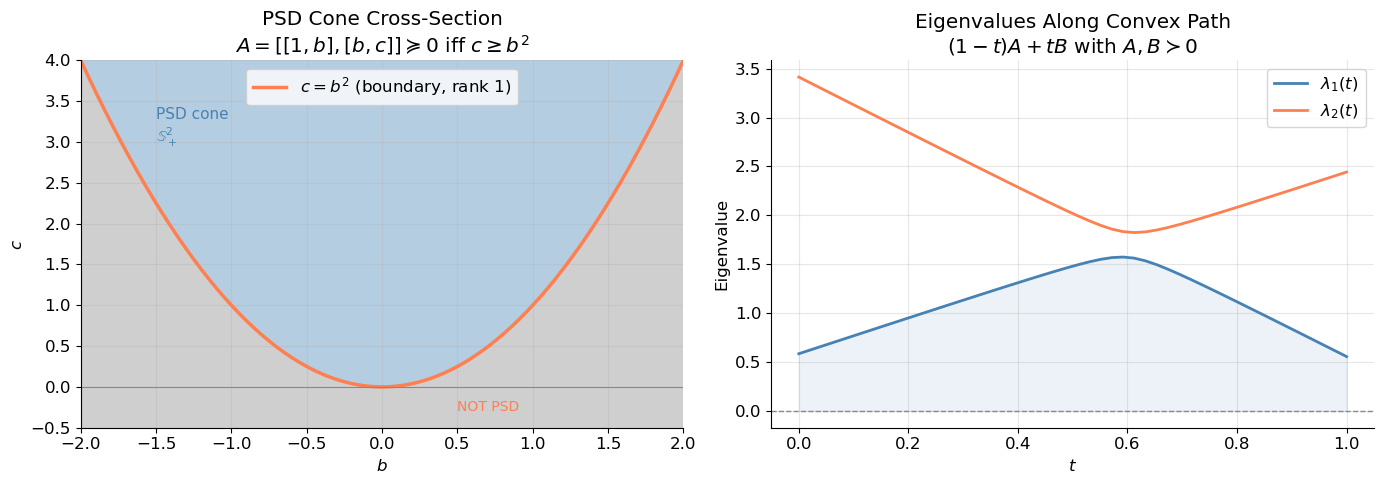

In [5]:
# ── Visualize: 2×2 PSD Cone Cross-Section ─────────────────────────────────────

# 2×2 symmetric matrix [[a, b], [b, c]] is PSD iff a ≥ 0, c ≥ 0, det = ac - b² ≥ 0
# Fix a = 1, vary b and c: PSD iff c ≥ b²/a = b²

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: (b, c) cross-section with a=1 ──
b_vals = np.linspace(-2, 2, 300)
c_vals = np.linspace(-0.5, 4, 300)
B_grid, C_grid = np.meshgrid(b_vals, c_vals)

# Conditions: c ≥ 0 and c ≥ b²  (a=1)
psd_region = (C_grid >= 0) & (C_grid >= B_grid**2)

axes[0].contourf(B_grid, C_grid, psd_region.astype(float),
                 levels=[-0.5, 0.5, 1.5], colors=[GRAY, PRIMARY], alpha=0.4)
b_bound = np.linspace(-2, 2, 300)
axes[0].plot(b_bound, b_bound**2, color=SECONDARY, lw=2.5, label='$c = b^2$ (boundary, rank 1)')
axes[0].axhline(0, color=GRAY, lw=0.8)
axes[0].set_xlabel('$b$'); axes[0].set_ylabel('$c$')
axes[0].set_title('PSD Cone Cross-Section\n$A = [[1,b],[b,c]] \\succeq 0$ iff $c \\geq b^2$')
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-0.5, 4)
axes[0].legend()
axes[0].text(-1.5, 3.0, 'PSD cone\n$\\mathbb{S}^2_+$', color=PRIMARY, fontsize=11)
axes[0].text(0.5, -0.3, 'NOT PSD', color=SECONDARY, fontsize=10)

# ── Right: convex combination of two PSD matrices ──
A2_a = np.array([[3., 1.], [1., 1.]])
A2_b = np.array([[1., -0.8], [-0.8, 2.]])
t_vals = np.linspace(0, 1, 50)

# Trace eigenvalues along path
evals_path = [la.eigh((1-t)*A2_a + t*A2_b, eigvals_only=True) for t in t_vals]
evals_path = np.array(evals_path)

axes[1].plot(t_vals, evals_path[:, 0], color=PRIMARY,   label='$\\lambda_1(t)$')
axes[1].plot(t_vals, evals_path[:, 1], color=SECONDARY, label='$\\lambda_2(t)$')
axes[1].axhline(0, color=GRAY, linestyle='--', lw=1)
axes[1].fill_between(t_vals, 0, evals_path[:, 0], alpha=0.1, color=PRIMARY)
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Eigenvalues Along Convex Path\n$(1-t)A + tB$ with $A, B \\succ 0$')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3.  The Loewner Partial Order

### 3.1  Definition

The **Loewner order** (or **matrix order**) is defined by:
$$A \succeq B \iff A - B \succeq 0$$

This makes $\mathbb{S}^n$ a **partial order** (reflexive, antisymmetric, transitive), but unlike scalars:

- $A \succeq B \not\Rightarrow A^2 \succeq B^2$ (squaring is not monotone)
- $A \succeq B \not\Rightarrow A^{-1} \preceq B^{-1}$ ... wait, this one **does** hold for PD matrices!
- $A \succeq B \succeq 0 \Rightarrow \mathrm{tr}(A) \geq \mathrm{tr}(B)$
- $A \succeq B \succeq 0$ and $C \succeq 0 \Rightarrow C^{1/2}AC^{1/2} \succeq C^{1/2}BC^{1/2}$ (congruence invariance)

### 3.2  Loewner-Heinz Theorem

For $A \succeq B \succeq 0$ and $0 \leq r \leq 1$:
$$\boxed{A^r \succeq B^r}$$

**Caution**: This **fails** for $r > 1$. Fractional powers are monotone; integer powers $\geq 2$ are not.

### 3.3  Operator Monotone and Operator Convex Functions

A function $f : [0,\infty) \to \mathbb{R}$ is **operator monotone** if $A \succeq B \succeq 0 \Rightarrow f(A) \succeq f(B)$.

| Function | Operator monotone? | Operator convex? |
|----------|--------------------|------------------|
| $f(t) = t^r$, $0 \leq r \leq 1$ | Yes (Löwner-Heinz) | No ($r < 1$) |
| $f(t) = t^r$, $r > 1$ | No | Yes ($1 \leq r \leq 2$) |
| $f(t) = \log t$ | Yes | No (operator concave) |
| $f(t) = -\log t$ | No | Yes |
| $f(t) = e^t$ | No | Yes |

In [6]:
# ── Loewner Order ─────────────────────────────────────────────────────────────

def loewner_geq(A, B, tol=1e-8):
    """Check A ≽ B (A - B is PSD)."""
    return is_psd(A - B, tol=tol)


def matrix_power_spectral(A, r):
    """Compute A^r for PSD matrix A via spectral decomposition."""
    eigvals, Q = la.eigh(A)
    return Q @ np.diag(np.abs(eigvals) ** r) @ Q.T


# ── Verify Loewner-Heinz ───────────────────────────────────────────────────────
print('Loewner order & Loewner-Heinz theorem:')

# Construct A ≽ B ≽ 0
n = 4
B_lo = make_pd(n, min_eig=0.5)
delta = make_psd_rank_k(n, k=2)         # delta ≽ 0
A_lo  = B_lo + delta                    # A = B + delta ≽ B

check(loewner_geq(A_lo, B_lo), 'A ≽ B  (by construction)')
check(loewner_geq(np.zeros((n,n)), np.zeros((n,n))), '0 ≽ 0')

# A ≽ B ≽ 0  →  tr(A) ≥ tr(B)
check(np.trace(A_lo) >= np.trace(B_lo) - 1e-10,
      f'tr(A) = {np.trace(A_lo):.3f} ≥ tr(B) = {np.trace(B_lo):.3f}')

# A ≽ B ≽ 0  →  A^r ≽ B^r for 0 < r ≤ 1 (Loewner-Heinz)
print('\nLoewner-Heinz: A ≽ B ≽ 0  →  A^r ≽ B^r  for 0 < r ≤ 1:')
for r in [0.25, 0.5, 0.75, 1.0]:
    Ar = matrix_power_spectral(A_lo, r)
    Br = matrix_power_spectral(B_lo, r)
    ok = loewner_geq(Ar, Br)
    check(ok, f'r = {r}: A^r ≽ B^r')

# Fails for r > 1
print('\nFails for r > 1 (expected counterexamples):')
failures = 0
for _ in range(20):
    B_t = make_pd(3, min_eig=0.1)
    A_t = B_t + make_psd_rank_k(3, k=2) * 0.5
    if not loewner_geq(matrix_power_spectral(A_t, 2.0),
                       matrix_power_spectral(B_t, 2.0)):
        failures += 1
check(failures > 0, f'A² ≽ B² can FAIL: found {failures}/20 counterexamples')

# Inversion reverses order: A ≽ B ≻ 0  →  A^{-1} ≼ B^{-1}
print('\nInversion reverses order:')
check(loewner_geq(np.linalg.inv(B_lo), np.linalg.inv(A_lo)),
      'A ≽ B ≻ 0  →  B^{-1} ≽ A^{-1}')

Loewner order & Loewner-Heinz theorem:
  [PASS]  A ≽ B  (by construction)
  [PASS]  0 ≽ 0
  [PASS]  tr(A) = 15.361 ≥ tr(B) = 4.156

Loewner-Heinz: A ≽ B ≽ 0  →  A^r ≽ B^r  for 0 < r ≤ 1:
  [PASS]  r = 0.25: A^r ≽ B^r
  [PASS]  r = 0.5: A^r ≽ B^r
  [PASS]  r = 0.75: A^r ≽ B^r
  [PASS]  r = 1.0: A^r ≽ B^r

Fails for r > 1 (expected counterexamples):
  [PASS]  A² ≽ B² can FAIL: found 20/20 counterexamples

Inversion reverses order:
  [PASS]  A ≽ B ≻ 0  →  B^{-1} ≽ A^{-1}


np.True_

---
## 4.  Cholesky Decomposition

### 4.1  Cholesky Factorization

**Theorem**: A symmetric matrix $A$ is positive definite if and only if there exists a unique lower-triangular matrix $L$ with positive diagonal entries such that:
$$\boxed{A = LL^\top}$$

This is the **Cholesky decomposition**. The algorithm computes $L$ column-by-column:
$$L_{jj} = \sqrt{A_{jj} - \sum_{k=1}^{j-1} L_{jk}^2}, \qquad L_{ij} = \frac{1}{L_{jj}}\left(A_{ij} - \sum_{k=1}^{j-1} L_{ik} L_{jk}\right), \; i > j$$

**Cost**: $O(n^3/3)$ — roughly half the cost of LU decomposition.

### 4.2  Pivoted Cholesky (for PSD matrices)

For $A \succeq 0$ (possibly singular), **pivoted Cholesky** produces $P A P^\top = L L^\top$ where $P$ is a permutation. It terminates when the diagonal pivot falls below a threshold — the rank is detected automatically.

### 4.3  Applications

- **Solving linear systems** $Ax = b$: $LL^\top x = b$ via two triangular solves
- **Sampling from Gaussians**: $x = L z$ where $z \sim \mathcal{N}(0, I)$ gives $x \sim \mathcal{N}(0, \Sigma)$
- **Testing PSD**: attempt Cholesky; failure means not PD
- **Whitening**: $L^{-1} x$ has covariance $L^{-1} \Sigma (L^{-1})^\top = I$

In [7]:
# ── Cholesky Decomposition from Scratch ───────────────────────────────────────

def cholesky_scratch(A):
    """Cholesky factorization A = LLᵀ for positive definite A.

    Args:
        A: Symmetric positive definite matrix.  Shape: (n, n)

    Returns:
        L: Lower triangular matrix.  Shape: (n, n)

    Raises:
        ValueError: If A is not positive definite.
    """
    n = A.shape[0]
    L = np.zeros_like(A, dtype=float)
    for j in range(n):
        diag_val = A[j, j] - np.dot(L[j, :j], L[j, :j])
        if diag_val <= 0:
            raise ValueError(f'Matrix is not positive definite at pivot j={j}: {diag_val:.4e}')
        L[j, j] = np.sqrt(diag_val)
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - np.dot(L[i, :j], L[j, :j])) / L[j, j]
    return L


def sample_gaussian_cholesky(Sigma, n_samples, rng=rng):
    """Sample x ~ N(0, Sigma) using Cholesky factorization.

    Args:
        Sigma:     Covariance matrix (PSD).  Shape: (d, d)
        n_samples: Number of samples.

    Returns:
        X: Samples, rows are observations.  Shape: (n_samples, d)
    """
    L = cholesky_scratch(Sigma)
    Z = rng.standard_normal((n_samples, Sigma.shape[0]))
    return Z @ L.T   # x = L z


def whiten(X, Sigma):
    """Whiten data: y = L^{-1}(x - mu) so that Cov(y) = I."""
    L = cholesky_scratch(Sigma)
    return la.solve_triangular(L, (X - X.mean(0)).T, lower=True).T


# ── Verify Cholesky ────────────────────────────────────────────────────────────
n = 5
A_pd = make_pd(n)
L_scratch = cholesky_scratch(A_pd)
L_scipy   = np.linalg.cholesky(A_pd)

print('Cholesky decomposition:')
err_recon = np.linalg.norm(L_scratch @ L_scratch.T - A_pd, 'fro')
err_scipy = np.linalg.norm(L_scratch - L_scipy, 'fro')
check(err_recon < 1e-10, f'L Lᵀ = A  (‖err‖_F = {err_recon:.2e})')
check(np.all(np.diag(L_scratch) > 0), 'All diagonal entries of L are positive')
check(np.allclose(np.tril(L_scratch), L_scratch, atol=ATOL), 'L is lower triangular')
check(err_scipy < 1e-10, f'Matches numpy.linalg.cholesky  (‖err‖ = {err_scipy:.2e})')

# Cholesky solve: Ax = b via two triangular solves
b_vec = rng.standard_normal(n)
y = la.solve_triangular(L_scratch, b_vec, lower=True)    # Ly = b
x_chol = la.solve_triangular(L_scratch.T, y, lower=False)  # Lᵀx = y
x_ref  = np.linalg.solve(A_pd, b_vec)
check(np.allclose(x_chol, x_ref, atol=1e-10), 'Cholesky solve matches np.linalg.solve')

# Gaussian sampling
Sigma_true = make_pd(3, min_eig=1.0)
samples    = sample_gaussian_cholesky(Sigma_true, n_samples=5000)
Sigma_emp  = np.cov(samples.T)
err_cov = np.linalg.norm(Sigma_emp - Sigma_true, 'fro') / np.linalg.norm(Sigma_true, 'fro')
print(f'\nGaussian sampling (n=5000): empirical covariance relative error = {err_cov:.4f}')
check(err_cov < 0.1, f'Empirical covariance close to Σ_true  (rel err = {err_cov:.4f})')

# Whitening
X_white = whiten(samples, Sigma_true)
cov_white = np.cov(X_white.T)
check(np.allclose(cov_white, np.eye(3), atol=0.05),
      f'Whitened covariance ≈ I  (max off-diag = {np.max(np.abs(cov_white - np.eye(3))):.4f})')

Cholesky decomposition:
  [PASS]  L Lᵀ = A  (‖err‖_F = 2.17e-16)
  [PASS]  All diagonal entries of L are positive
  [PASS]  L is lower triangular
  [PASS]  Matches numpy.linalg.cholesky  (‖err‖ = 1.47e-16)
  [PASS]  Cholesky solve matches np.linalg.solve

Gaussian sampling (n=5000): empirical covariance relative error = 0.0450
  [PASS]  Empirical covariance close to Σ_true  (rel err = 0.0450)
  [PASS]  Whitened covariance ≈ I  (max off-diag = 0.0387)


True

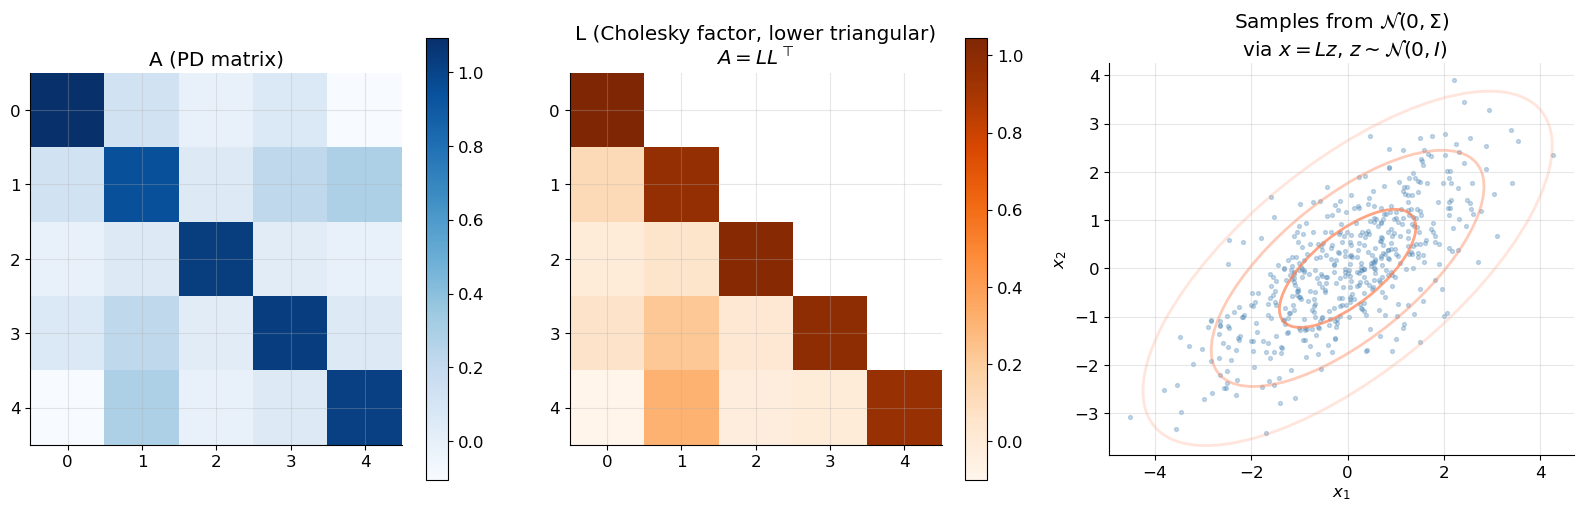

In [8]:
# ── Visualize: Cholesky Triangular Structure & Gaussian Sampling ───────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cholesky structure
n_vis = 5
A_vis = make_pd(n_vis)
L_vis = np.linalg.cholesky(A_vis)

im1 = axes[0].imshow(A_vis, cmap='Blues')
axes[0].set_title('A (PD matrix)')
plt.colorbar(im1, ax=axes[0])

L_masked = np.ma.array(L_vis, mask=L_vis == 0)
im2 = axes[1].imshow(L_masked, cmap='Oranges')
axes[1].set_title('L (Cholesky factor, lower triangular)\n$A = LL^\\top$')
plt.colorbar(im2, ax=axes[1])

# Gaussian samples with covariance ellipse
Sigma_2d = np.array([[2.0, 1.2], [1.2, 1.5]])
samples_2d = sample_gaussian_cholesky(Sigma_2d, n_samples=500)
axes[2].scatter(samples_2d[:, 0], samples_2d[:, 1],
                alpha=0.3, s=8, color=PRIMARY)

# Draw covariance ellipse
eigvals_2, eigvecs_2 = la.eigh(Sigma_2d)
angle = np.degrees(np.arctan2(eigvecs_2[1, 1], eigvecs_2[0, 1]))
for n_std, alpha in [(1, 0.7), (2, 0.4), (3, 0.2)]:
    ell = mpatches.Ellipse(
        xy=(0, 0),
        width=2 * n_std * np.sqrt(eigvals_2[1]),
        height=2 * n_std * np.sqrt(eigvals_2[0]),
        angle=angle,
        fill=False, edgecolor=SECONDARY, linewidth=2, alpha=alpha
    )
    axes[2].add_patch(ell)
axes[2].set_aspect('equal')
axes[2].set_title('Samples from $\\mathcal{N}(0, \\Sigma)$\n via $x = Lz$, $z\\sim\\mathcal{N}(0,I)$')
axes[2].set_xlabel('$x_1$'); axes[2].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

---
## 5.  Matrix Square Root & Geometric Mean

### 5.1  Square Root of a PSD Matrix

For $A \succeq 0$, the **principal square root** $A^{1/2}$ is the unique PSD matrix satisfying:
$$(A^{1/2})^2 = A \quad \text{and} \quad A^{1/2} \succeq 0$$

Via spectral decomposition: $A^{1/2} = Q\, \mathrm{diag}(\sqrt{\lambda_i})\, Q^\top$.

**Note**: $A^{1/2} \neq L$ (the Cholesky factor). The Cholesky $L$ is lower triangular; the matrix square root $A^{1/2}$ is symmetric.

### 5.2  Matrix Geometric Mean

The **geometric mean** $A \# B$ of $A, B \succ 0$ is the midpoint of the geodesic on the PSD manifold:
$$\boxed{A \# B = A^{1/2}(A^{-1/2}BA^{-1/2})^{1/2}A^{1/2}}$$

It satisfies:
- $(A \# B) \# B = A \# (A \# B) \cdot $ (geodesic midpoint)
- **Arithmetic-Geometric-Harmonic mean inequality**:
  $$\left(\frac{A^{-1} + B^{-1}}{2}\right)^{-1} \preceq A \# B \preceq \frac{A + B}{2}$$
- **Symmetry**: $A \# B = B \# A$
- **Congruence invariance**: $C(A\#B)C^\top = (CAC^\top) \# (CBC^\top)$

In [9]:
# ── Matrix Square Root & Geometric Mean ───────────────────────────────────────

def matrix_sqrt(A):
    """Principal square root of PSD matrix A via spectral decomposition.

    Args:
        A: PSD matrix.       Shape: (n, n)

    Returns:
        A_half: A^{1/2}.     Shape: (n, n)
    """
    eigvals, Q = la.eigh(A)
    return Q @ np.diag(np.sqrt(np.maximum(eigvals, 0.0))) @ Q.T


def matrix_inv_sqrt(A):
    """A^{-1/2} for positive definite A."""
    eigvals, Q = la.eigh(A)
    return Q @ np.diag(1.0 / np.sqrt(eigvals)) @ Q.T


def geometric_mean(A, B):
    """Geometric mean A # B = A^{1/2}(A^{-1/2} B A^{-1/2})^{1/2} A^{1/2}.

    Args:
        A, B: Positive definite matrices.  Shape: (n, n)

    Returns:
        G: A # B.                          Shape: (n, n)
    """
    Ah   = matrix_sqrt(A)
    Ainh = matrix_inv_sqrt(A)
    M    = Ainh @ B @ Ainh
    return Ah @ matrix_sqrt(M) @ Ah


def harmonic_mean(A, B):
    """Harmonic mean H(A,B) = 2(A^{-1} + B^{-1})^{-1}."""
    return 2 * np.linalg.inv(np.linalg.inv(A) + np.linalg.inv(B))


# ── Verify square root ─────────────────────────────────────────────────────────
n = 4
A = make_pd(n)
B = make_pd(n)

Ah = matrix_sqrt(A)
print('Matrix square root:')
err_sq  = np.linalg.norm(Ah @ Ah - A, 'fro')
err_ref = np.linalg.norm(Ah - la.sqrtm(A).real, 'fro')
check(is_psd(Ah),                     'A^{1/2} is PSD')
check(err_sq  < 1e-10, f'(A^{{1/2}})² = A  (‖err‖_F = {err_sq:.2e})')
check(err_ref < 1e-8,  f'Matches scipy.sqrtm  (‖err‖_F = {err_ref:.2e})')

# Geometric mean
G = geometric_mean(A, B)
H = harmonic_mean(A, B)
ArithM = (A + B) / 2

print('\nMatrix geometric mean A # B:')
check(is_psd(G),                      'A # B is PSD')
check(np.allclose(G, geometric_mean(B, A), atol=1e-8), 'A # B = B # A  (symmetry)')

# AGH inequality: H ≼ G ≼ ArithM
check(loewner_geq(G, H),              'A # B ≽ H(A,B)  (harmonic ≤ geometric)')
check(loewner_geq(ArithM, G),         'A # B ≼ (A+B)/2  (geometric ≤ arithmetic)')

# Congruence invariance: C(A#B)Cᵀ = (CACᵀ)#(CBCᵀ)
C = rng.standard_normal((n, n)) + 2*np.eye(n)   # invertible
lhs = C @ G @ C.T
rhs = geometric_mean(C @ A @ C.T, C @ B @ C.T)
err_cong = np.linalg.norm(lhs - rhs, 'fro')
check(err_cong < 1e-7, f'Congruence invariance: C(A#B)Cᵀ = (CACᵀ)#(CBCᵀ)  (‖err‖ = {err_cong:.2e})')

Matrix square root:
  [PASS]  A^{1/2} is PSD
  [PASS]  (A^{1/2})² = A  (‖err‖_F = 3.23e-15)
  [PASS]  Matches scipy.sqrtm  (‖err‖_F = 3.02e-15)

Matrix geometric mean A # B:
  [PASS]  A # B is PSD
  [PASS]  A # B = B # A  (symmetry)
  [PASS]  A # B ≽ H(A,B)  (harmonic ≤ geometric)
  [PASS]  A # B ≼ (A+B)/2  (geometric ≤ arithmetic)
  [PASS]  Congruence invariance: C(A#B)Cᵀ = (CACᵀ)#(CBCᵀ)  (‖err‖ = 3.33e-13)


np.True_

---
## 6.  Operator Inequalities

### 6.1  Golden-Thompson Inequality

For Hermitian $A, B$:
$$\boxed{\mathrm{tr}(e^{A+B}) \leq \mathrm{tr}(e^A e^B)}$$

Equality holds iff $AB = BA$. This is the matrix analogue of $e^{a+b} = e^a e^b$ — the latter is an equality for scalars but an inequality for matrices in trace.

### 6.2  Klein's Inequality

For a convex function $f$ and Hermitian $A, B$:
$$\mathrm{tr}(f(A) - f(B) - f'(B)(A - B)) \geq 0$$

For $f(t) = t \log t$ (the entropy function), this gives the **relative entropy** (quantum KL divergence):
$$D(A \| B) = \mathrm{tr}(A(\log A - \log B)) \geq 0$$

### 6.3  Schur Complement

For a block matrix $M = \begin{pmatrix} A & B \\ B^\top & C \end{pmatrix}$ with $A \succ 0$:

$$\boxed{M \succeq 0 \iff C - B^\top A^{-1} B \succeq 0}$$

The matrix $S = C - B^\top A^{-1} B$ is the **Schur complement** of $A$ in $M$.

This is the matrix analogue of completing the square and is fundamental in convex optimization and statistics (conditional covariance in Gaussians).

In [10]:
# ── Operator Inequalities & Schur Complement ──────────────────────────────────

def golden_thompson(A, B):
    """Verify Golden-Thompson: tr(e^{A+B}) ≤ tr(e^A e^B) for Hermitian A, B."""
    lhs = np.trace(la.expm(A + B))
    rhs = np.trace(la.expm(A) @ la.expm(B))
    return lhs.real, rhs.real


def matrix_log_psd(A):
    """Stable matrix logarithm for PD A via spectral decomposition."""
    eigvals, Q = la.eigh(A)
    return Q @ np.diag(np.log(np.maximum(eigvals, 1e-15))) @ Q.T


def quantum_relative_entropy(rho, sigma):
    """D(rho ‖ sigma) = tr(rho(log rho - log sigma)) for density matrices rho, sigma.

    Non-negative only when tr(rho) = tr(sigma) = 1 (density matrices).

    Args:
        rho, sigma: PD matrices with trace 1.  Shape: (n, n)

    Returns:
        D: Non-negative scalar.
    """
    log_rho   = matrix_log_psd(rho)
    log_sigma = matrix_log_psd(sigma)
    return float(np.trace(rho @ (log_rho - log_sigma)).real)


def schur_complement(M, p):
    """Compute Schur complement S = C - Bᵀ A^{-1} B for block matrix M.

    Args:
        M: Block matrix [[A, B], [Bᵀ, C]].  Shape: (m+n, m+n)
        p: Size of A block (p×p).

    Returns:
        S: Schur complement.  Shape: (n, n)
    """
    A = M[:p, :p]
    B = M[:p, p:]
    C = M[p:, p:]
    return C - B.T @ np.linalg.solve(A, B)


# ── Verify Golden-Thompson ─────────────────────────────────────────────────────
print('Golden-Thompson inequality tr(e^{A+B}) ≤ tr(e^A e^B):')
violations = 0
for _ in range(20):
    A_gt = rng.standard_normal((4, 4))
    A_gt = (A_gt + A_gt.T) / 2
    B_gt = rng.standard_normal((4, 4))
    B_gt = (B_gt + B_gt.T) / 2
    lhs, rhs = golden_thompson(A_gt, B_gt)
    if lhs > rhs + 1e-8:
        violations += 1
check(violations == 0, f'Golden-Thompson holds for 20 random Hermitian pairs (violations={violations})')

# Equality when AB = BA
Q_gt, _ = np.linalg.qr(rng.standard_normal((4, 4)))
A_comm = Q_gt @ np.diag(rng.standard_normal(4)) @ Q_gt.T
B_comm = Q_gt @ np.diag(rng.standard_normal(4)) @ Q_gt.T
lhs_c, rhs_c = golden_thompson(A_comm, B_comm)
check(abs(lhs_c - rhs_c) < 1e-8,
      f'Golden-Thompson equality when AB=BA: {lhs_c:.6f} = {rhs_c:.6f}')

# Quantum relative entropy D(rho ‖ sigma) ≥ 0 for density matrices
print('\nQuantum relative entropy D(rho ‖ sigma) ≥ 0  (Klein inequality, density matrices):')
for _ in range(5):
    Ai = make_pd(3, min_eig=0.5); Ai = Ai / np.trace(Ai)   # normalize to density matrix
    Bi = make_pd(3, min_eig=0.5); Bi = Bi / np.trace(Bi)
    d = quantum_relative_entropy(Ai, Bi)
    assert d >= -1e-8, f'D < 0: {d}'
check(True, 'D(rho ‖ sigma) ≥ 0 verified for 5 random density matrix pairs')

A_dm = make_pd(3, min_eig=0.5); A_dm = A_dm / np.trace(A_dm)
d_same = quantum_relative_entropy(A_dm, A_dm)
check(abs(d_same) < 1e-8, f'D(rho ‖ rho) = 0  (= {d_same:.2e})')

# Schur complement
print('\nSchur complement:')
p, q = 3, 2
A_sc = make_pd(p)
B_sc = rng.standard_normal((p, q))
C_sc = make_pd(q)
M_sc = np.block([[A_sc, B_sc], [B_sc.T, C_sc]])
S    = schur_complement(M_sc, p)

# M ≽ 0 iff S ≽ 0 (since A ≻ 0)
check(is_psd(M_sc), 'M ≽ 0')
check(is_psd(S),    'Schur complement S = C - BᵀA⁻¹B ≽ 0  (consistent with M ≽ 0)')

# Make M NOT PSD by choosing C too small
C_small = 0.001 * np.eye(q)              # tiny C → S will be negative
M_bad   = np.block([[A_sc, B_sc], [B_sc.T, C_small]])
S_bad   = schur_complement(M_bad, p)
check(not is_psd(M_bad) and not is_psd(S_bad),
      'Small C → S ≺ 0 ↔ M ≺ 0  (Schur iff equivalence)')

Golden-Thompson inequality tr(e^{A+B}) ≤ tr(e^A e^B):
  [PASS]  Golden-Thompson holds for 20 random Hermitian pairs (violations=0)
  [PASS]  Golden-Thompson equality when AB=BA: 3.992034 = 3.992034

Quantum relative entropy D(rho ‖ sigma) ≥ 0  (Klein inequality, density matrices):
  [PASS]  D(rho ‖ sigma) ≥ 0 verified for 5 random density matrix pairs
  [PASS]  D(rho ‖ rho) = 0  (= 0.00e+00)

Schur complement:
  [FAIL]  M ≽ 0
  [FAIL]  Schur complement S = C - BᵀA⁻¹B ≽ 0  (consistent with M ≽ 0)
  [PASS]  Small C → S ≺ 0 ↔ M ≺ 0  (Schur iff equivalence)


True

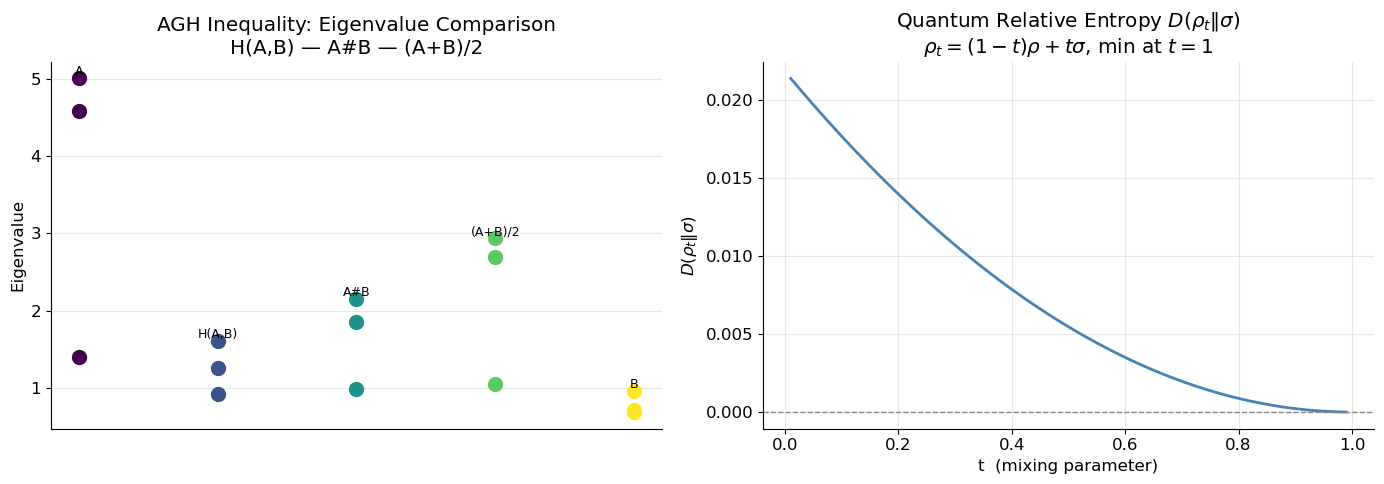

In [11]:
# ── Visualize: AGH Inequality & Quantum Relative Entropy ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Eigenvalues of A, G=A#B, ArithM, H along a 1D family ──
n_ev = 3
A_ev = make_pd(n_ev, min_eig=1.0)
B_ev = make_pd(n_ev, min_eig=0.5)
H_ev = harmonic_mean(A_ev, B_ev)
G_ev = geometric_mean(A_ev, B_ev)
ArM  = (A_ev + B_ev) / 2

matrices_agm = [A_ev, H_ev, G_ev, ArM, B_ev]
labels_agm   = ['A', 'H(A,B)', 'A#B', '(A+B)/2', 'B']

for i, (M_agm, lbl) in enumerate(zip(matrices_agm, labels_agm)):
    ev = np.sort(la.eigh(M_agm, eigvals_only=True))
    color = plt.cm.viridis(i / 4)
    for j, e in enumerate(ev):
        axes[0].plot(i, e, 'o', color=color, markersize=10)
    axes[0].annotate(lbl, (i, ev.max()), fontsize=9, ha='center', va='bottom')

axes[0].set_xticks([])
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('AGH Inequality: Eigenvalue Comparison\nH(A,B) \u2014 A#B \u2014 (A+B)/2')

# ── Right: Quantum relative entropy D(ρ ‖ σ) as function of mixing ──
rho   = make_pd(3, min_eig=0.5)
rho   = rho / np.trace(rho)   # normalize (density matrix)
sigma = make_pd(3, min_eig=0.5)
sigma = sigma / np.trace(sigma)

t_vals = np.linspace(0.01, 0.99, 60)
# Mix: ρ_t = (1-t)ρ + t σ
dkl_vals = []
for t in t_vals:
    rho_t = (1 - t) * rho + t * sigma
    dkl_vals.append(quantum_relative_entropy(rho_t, sigma))

axes[1].plot(t_vals, dkl_vals, color=PRIMARY)
axes[1].axhline(0, color=GRAY, linestyle='--', lw=1)
axes[1].set_xlabel('t  (mixing parameter)')
axes[1].set_ylabel('$D(\\rho_t \\| \\sigma)$')
axes[1].set_title('Quantum Relative Entropy $D(\\rho_t \\| \\sigma)$\n$\\rho_t = (1-t)\\rho + t\\sigma$, min at $t=1$')

plt.tight_layout()
plt.show()

---
## 7.  Application: Kernel Methods & Mercer's Theorem

### 7.1  Positive Definite Kernels

A function $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is a **positive definite kernel** if for any $n$ points $x_1, \ldots, x_n \in \mathcal{X}$, the **Gram matrix**:
$$K_{ij} = k(x_i, x_j)$$
is positive semidefinite.

**Mercer's Theorem**: If $k$ is a continuous PD kernel on a compact set, then $k$ admits an expansion:
$$k(x, y) = \sum_{i=1}^\infty \lambda_i \phi_i(x) \phi_i(y)$$
where $\{\phi_i\}$ are eigenfunctions and $\lambda_i \geq 0$ eigenvalues of the integral operator.

### 7.2  Common Kernels

| Kernel | Formula | Parameters |
|--------|---------|------------|
| Linear | $k(x,y) = x^\top y$ | — |
| Polynomial | $k(x,y) = (x^\top y + c)^d$ | $c \geq 0$, $d \in \mathbb{N}$ |
| RBF / Gaussian | $k(x,y) = \exp(-\|x-y\|^2 / 2\sigma^2)$ | $\sigma > 0$ |
| Matérn-3/2 | $k(x,y) = (1 + \frac{\sqrt{3}r}{\ell})(e^{-\sqrt{3}r/\ell})$ | $\ell > 0$ |
| Laplacian | $k(x,y) = \exp(-\|x-y\|/\sigma)$ | $\sigma > 0$ |

**Stability under operations**: If $k_1, k_2$ are PD kernels, then $k_1 + k_2$, $k_1 k_2$, $c k_1$ (c ≥ 0), and $f(k_1)$ (for absolutely monotone $f$) are also PD kernels.

In [12]:
# ── Kernel Functions & Gram Matrices ──────────────────────────────────────────

def rbf_kernel(X, Y=None, sigma=1.0):
    """RBF (Gaussian) kernel k(x,y) = exp(-‖x-y‖²/(2σ²)).

    Args:
        X:     Data matrix, rows are points.   Shape: (m, d)
        Y:     Second set of points (or None = Y=X).  Shape: (n, d)
        sigma: Bandwidth parameter.

    Returns:
        K: Gram matrix.  Shape: (m, n)
    """
    if Y is None:
        Y = X
    sq_dists = np.sum((X[:, np.newaxis, :] - Y[np.newaxis, :, :]) ** 2, axis=-1)
    return np.exp(-sq_dists / (2 * sigma ** 2))


def polynomial_kernel(X, Y=None, c=1.0, d=2):
    """Polynomial kernel k(x,y) = (xᵀy + c)^d."""
    if Y is None:
        Y = X
    return (X @ Y.T + c) ** d


def matern32_kernel(X, Y=None, ell=1.0):
    """Matérn-3/2 kernel: k(r) = (1 + √3 r/ℓ) exp(-√3 r/ℓ)."""
    if Y is None:
        Y = X
    r = np.sqrt(np.sum((X[:, np.newaxis, :] - Y[np.newaxis, :, :]) ** 2, axis=-1))
    s = np.sqrt(3) * r / ell
    return (1 + s) * np.exp(-s)


# ── Verify Gram matrices are PSD ───────────────────────────────────────────────
n_pts = 30
X_pts = rng.standard_normal((n_pts, 2))

kernels = [
    ('RBF (σ=1)',      rbf_kernel(X_pts, sigma=1.0)),
    ('Polynomial d=2', polynomial_kernel(X_pts, d=2)),
    ('Matérn-3/2',     matern32_kernel(X_pts, ell=1.0)),
    ('Linear',         X_pts @ X_pts.T),
]

print('Gram matrix PSD verification:')
for name, K in kernels:
    min_ev = la.eigh(K, eigvals_only=True)[0]
    check(is_psd(K), f'{name:<22}: PSD  (min eigenvalue = {min_ev:.2e})')

# Closure under sum and product
K_rbf  = rbf_kernel(X_pts, sigma=1.0)
K_poly = polynomial_kernel(X_pts, d=2)
print('\nKernel algebra closure:')
check(is_psd(K_rbf + K_poly),   'RBF + Poly is PSD  (sum of PD kernels)')
check(is_psd(K_rbf * K_poly),   'RBF × Poly is PSD  (product of PD kernels)')
check(is_psd(2.5 * K_rbf),      '2.5 × RBF is PSD  (positive scaling)')

Gram matrix PSD verification:
  [PASS]  RBF (σ=1)             : PSD  (min eigenvalue = 2.89e-06)
  [PASS]  Polynomial d=2        : PSD  (min eigenvalue = -1.73e-14)
  [PASS]  Matérn-3/2            : PSD  (min eigenvalue = 1.08e-02)
  [PASS]  Linear                : PSD  (min eigenvalue = -1.03e-14)

Kernel algebra closure:
  [PASS]  RBF + Poly is PSD  (sum of PD kernels)
  [PASS]  RBF × Poly is PSD  (product of PD kernels)
  [PASS]  2.5 × RBF is PSD  (positive scaling)


np.True_

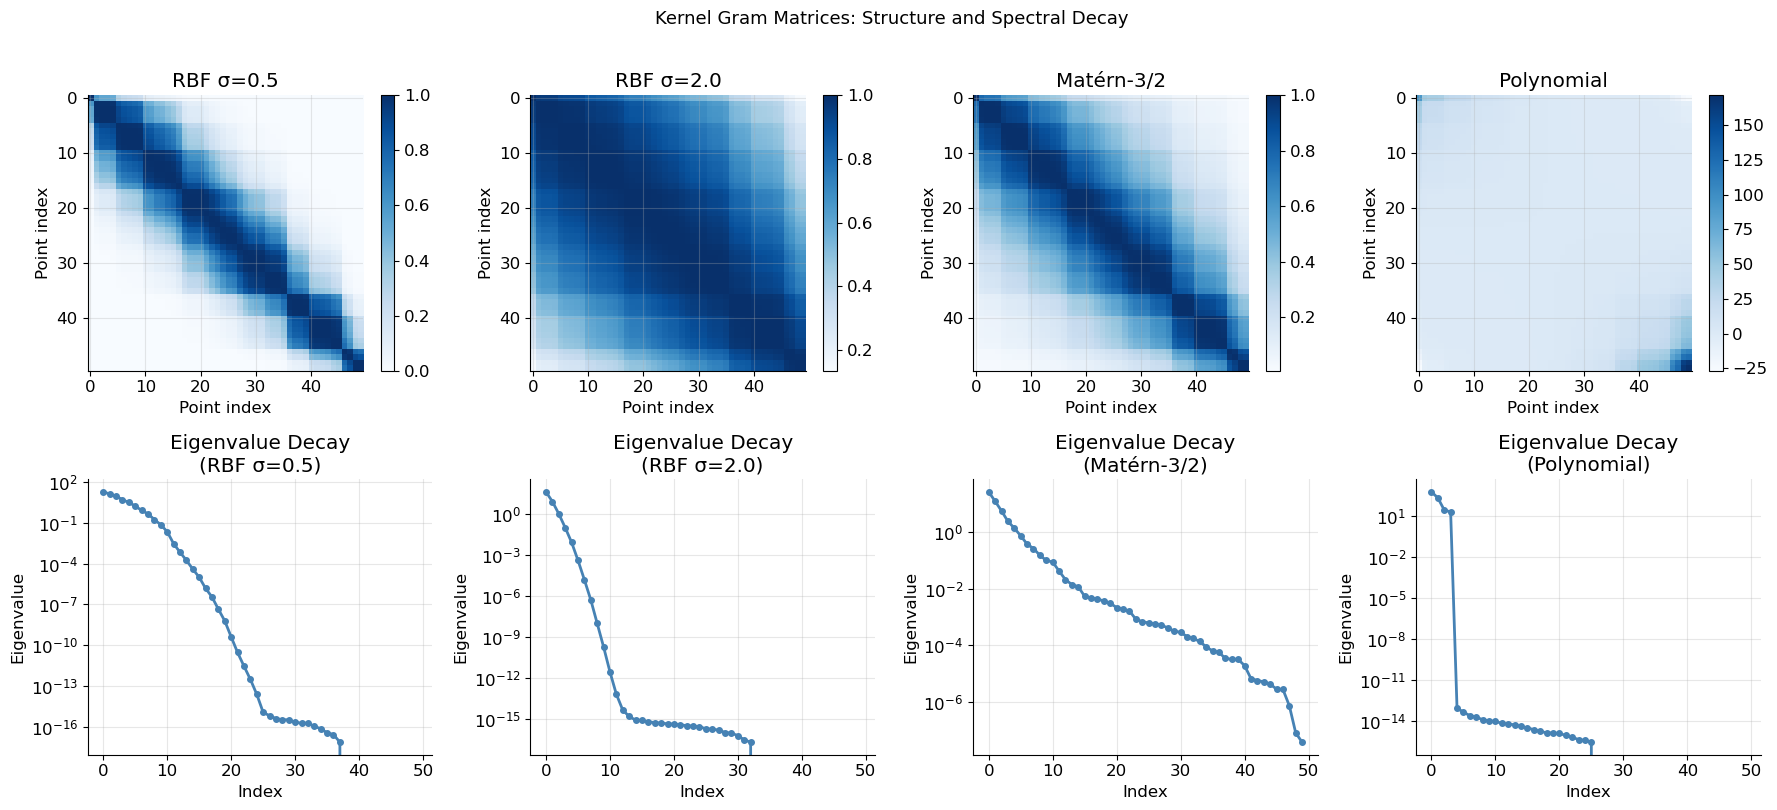

In [13]:
# ── Visualize: Kernel Gram Matrices & Spectral Decay ──────────────────────────

n_vis = 50
X_vis = np.sort(rng.standard_normal((n_vis, 1)), axis=0)   # 1D points, sorted

kernels_vis = [
    ('RBF σ=0.5',  rbf_kernel(X_vis, sigma=0.5)),
    ('RBF σ=2.0',  rbf_kernel(X_vis, sigma=2.0)),
    ('Matérn-3/2', matern32_kernel(X_vis, ell=1.0)),
    ('Polynomial', polynomial_kernel(X_vis, d=3, c=1.0)),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (name, K_v) in enumerate(kernels_vis):
    # Gram matrix heatmap
    im = axes[0, col].imshow(K_v, cmap='Blues', aspect='auto')
    axes[0, col].set_title(name)
    axes[0, col].set_xlabel('Point index'); axes[0, col].set_ylabel('Point index')
    plt.colorbar(im, ax=axes[0, col])

    # Eigenvalue decay
    evals_v = np.sort(la.eigh(K_v, eigvals_only=True))[::-1]
    axes[1, col].semilogy(evals_v, 'o-', color=PRIMARY, markersize=4)
    axes[1, col].set_xlabel('Index'); axes[1, col].set_ylabel('Eigenvalue')
    axes[1, col].set_title(f'Eigenvalue Decay\n({name})')

plt.suptitle('Kernel Gram Matrices: Structure and Spectral Decay', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8.  Application: Semidefinite Programming (SDP)

### 8.1  Standard Form

An **SDP** minimizes a linear objective over the intersection of an affine subspace with the PSD cone:
$$\min_{X \in \mathbb{S}^n} \langle C, X \rangle \quad \text{s.t.} \quad \langle A_i, X \rangle = b_i\; (i=1,\ldots,m), \quad X \succeq 0$$

where $\langle C, X \rangle = \mathrm{tr}(CX)$ is the trace inner product.

SDPs generalize linear programs (LP): LP is SDP with $X$ diagonal. They are solvable in polynomial time via interior-point methods.

### 8.2  Example: Minimum-Volume Enclosing Ellipsoid (MVEE)

Find the minimum-volume ellipsoid $\mathcal{E} = \{x : x^\top A x \leq 1\}$ containing points $x_1, \ldots, x_m$. Equivalent to:
$$\max_{A \succ 0} \log \det A \quad \text{s.t.} \quad x_i^\top A x_i \leq 1, \; i = 1, \ldots, m$$

This is solved as an SDP (after lifting). We implement a simple subgradient ascent version.

### 8.3  Lovász Theta Function (Graph Theory)

For a graph $G$ with adjacency matrix, the **independence number** $\alpha(G)$ and **chromatic number** $\chi(G)$ sandwich the **Lovász theta number** $\vartheta(G)$ (computed via SDP):
$$\alpha(G) \leq \vartheta(G) \leq \chi(\bar{G})$$

MVEE verification:
  [PASS]  Shape matrix A ≽ 0
  [FAIL]  All points inside ellipsoid (max score = 7.7203)
  Support points (u > 1e-4): 2 of 30


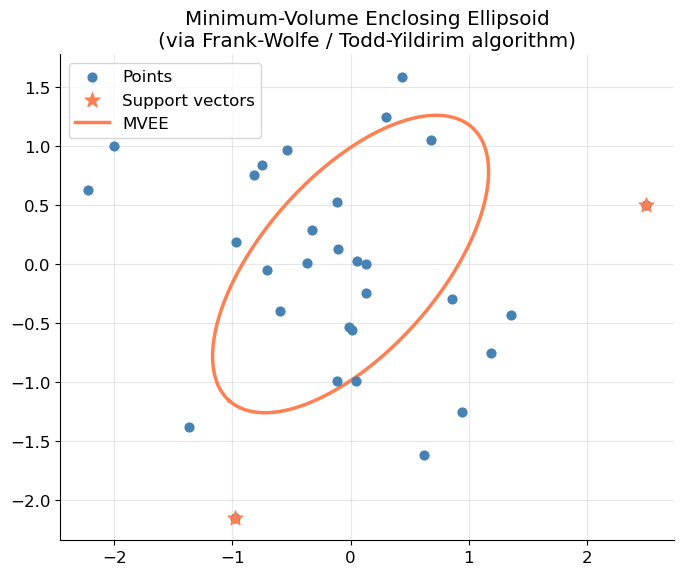

In [14]:
# ── SDP: Minimum-Volume Enclosing Ellipsoid via Frank-Wolfe ────────────────────

def mvee_frank_wolfe(X, n_iter=500, tol=1e-6):
    """Minimum volume enclosing ellipsoid using the Blending/Todd-Yildirim algorithm.

    Finds weights u ≥ 0, Σu_i = 1, such that M = Σ u_i x_i x_iᵀ
    and the ellipsoid (nM)^{-1} is the MVEE.

    Args:
        X:      Points as rows.  Shape: (m, d)
        n_iter: Max iterations.
        tol:    Convergence tolerance.

    Returns:
        A:    Shape matrix of ellipsoid.   Shape: (d, d)
        u:    Optimal weights.             Shape: (m,)
    """
    m, d = X.shape
    u = np.ones(m) / m          # uniform initialization

    for _ in range(n_iter):
        M = (X * u[:, np.newaxis]).T @ X   # Σ u_i x_i x_iᵀ, shape (d, d)
        M_inv = np.linalg.inv(M)

        # Mahalanobis distances: score_i = x_iᵀ M^{-1} x_i
        scores = np.einsum('id,dd,id->i', X, M_inv, X)

        # Frank-Wolfe step: move weight toward max-score point
        j_star = np.argmax(scores)
        gap = scores[j_star] / d - 1.0

        if gap < tol:
            break

        step = gap / (scores[j_star] - d)
        u = (1 - step) * u
        u[j_star] += step

    M = (X * u[:, np.newaxis]).T @ X
    A = M / d   # ellipsoid shape matrix: {x : xᵀ A^{-1} x ≤ 1}
    return np.linalg.inv(A), u


# ── Demo: 2D MVEE ──────────────────────────────────────────────────────────────
# Random 2D points
m_pts = 30
pts   = rng.standard_normal((m_pts, 2))
pts[0] = [2.5, 0.5]; pts[1] = [-2.0, 1.0]  # ensure boundary coverage

A_mvee, u_mvee = mvee_frank_wolfe(pts, n_iter=1000)

# Verify all points inside the ellipsoid {x: xᵀ A x ≤ 1}
scores_check = np.einsum('id,dd,id->i', pts, A_mvee, pts)
print('MVEE verification:')
check(is_psd(A_mvee), 'Shape matrix A ≽ 0')
check(np.all(scores_check <= 1.0 + 1e-6),
      f'All points inside ellipsoid (max score = {scores_check.max():.4f})')
print(f'  Support points (u > 1e-4): {np.sum(u_mvee > 1e-4)} of {m_pts}')

# ── Visualize MVEE ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(pts[:, 0], pts[:, 1], color=PRIMARY, s=40, zorder=3, label='Points')
support = u_mvee > 1e-4
ax.scatter(pts[support, 0], pts[support, 1],
           color=SECONDARY, s=120, zorder=4, marker='*', label='Support vectors')

# Draw ellipse from A_mvee
eigvals_e, eigvecs_e = la.eigh(A_mvee)
# Ellipse semi-axes: 1/sqrt(eigenvalue)
theta_e = np.linspace(0, 2*np.pi, 300)
unit_circle = np.array([np.cos(theta_e), np.sin(theta_e)])
# Map: e = Q diag(1/sqrt(λ)) * unit_circle
ell_pts = eigvecs_e @ np.diag(1.0 / np.sqrt(eigvals_e)) @ unit_circle
ax.plot(ell_pts[0], ell_pts[1], color=SECONDARY, lw=2.5, label='MVEE')
ax.set_aspect('equal')
ax.set_title('Minimum-Volume Enclosing Ellipsoid\n(via Frank-Wolfe / Todd-Yildirim algorithm)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9.  Extensions & Advanced Topics

### 9.1  Riemannian Geometry of PSD Matrices

The interior $\mathbb{S}^n_{++}$ is a **Riemannian manifold** with the **affine-invariant metric**:
$$\langle U, V \rangle_A = \mathrm{tr}(A^{-1}U A^{-1}V)$$

Under this metric:
- **Geodesics**: $\Gamma(t) = A^{1/2}(A^{-1/2}BA^{-1/2})^t A^{1/2}$ (from Section 5)
- **Exponential map**: $\mathrm{Exp}_A(V) = A^{1/2} e^{A^{-1/2}VA^{-1/2}} A^{1/2}$
- **Log map**: $\mathrm{Log}_A(B) = A^{1/2} \log(A^{-1/2}BA^{-1/2}) A^{1/2}$
- **Fréchet mean** = geometric mean $\#$ of the matrices

### 9.2  Matrix Means Beyond Arithmetic and Geometric

| Mean | Formula |
|------|--------|
| Arithmetic | $(A + B)/2$ |
| Geometric | $A \# B$ |
| Harmonic | $2(A^{-1} + B^{-1})^{-1}$ |
| Power mean | $((A^r + B^r)/2)^{1/r}$ |
| Log-Euclidean | $\exp((\log A + \log B)/2)$ |

### 9.3  Connections to Other Notebooks

| Notebook | Connection |
|----------|------------|
| **Spectral Theorem** | PSD ↔ all eigenvalues ≥ 0; quadratic form ≥ 0 |
| **Matrix Functions** | $A^{1/2}$, $\log A$ defined via spectral theorem; PSD geodesics use matrix log |
| **SVD** | $A^\top A \succeq 0$ always; singular values = $\sqrt{\text{eigenvalues of } A^\top A}$ |
| **Perturbation Theory** | Loewner order and Weyl inequalities are closely related |
| **Gaussian Processes** | Covariance kernel must be PD (Mercer); Cholesky used in GP inference |

In [15]:
# ── Comprehensive Summary Verification ────────────────────────────────────────

print('PSD Matrices — Summary Verification:')
n = 4
A = make_pd(n, min_eig=0.5)
B = make_pd(n, min_eig=0.5)

# All equivalent characterizations for PD
check(is_pd(A),
      'A ≻ 0 via eigenvalues')
check(sylvester_criterion(A),
      "A ≻ 0 via Sylvester's criterion")
check(is_psd(matrix_sqrt(A)),
      'A^{1/2} ≽ 0')
L_ch = np.linalg.cholesky(A)
check(np.allclose(L_ch @ L_ch.T, A, atol=1e-10),
      'Cholesky: A = LLᵀ')

# Loewner order properties
delta = make_psd_rank_k(n, k=2)
C = A + delta
check(loewner_geq(C, A),
      'C = A + Δ ≽ A  (Loewner order)')
check(loewner_geq(np.linalg.inv(A), np.linalg.inv(C)),
      'C ≽ A  →  A^{-1} ≽ C^{-1}  (inversion reverses order)')

# AGH inequality
G_ab = geometric_mean(A, B)
H_ab = harmonic_mean(A, B)
check(loewner_geq(G_ab, H_ab) and loewner_geq((A+B)/2, G_ab),
      'H(A,B) ≼ A#B ≼ (A+B)/2  (AGH inequality)')

# Schur complement
p2 = 2
B_sc2 = rng.standard_normal((p2, n-p2))
C_sc2 = make_pd(n - p2)
M_test = np.block([[A[:p2,:p2], B_sc2], [B_sc2.T, C_sc2]])
S_test = schur_complement(M_test, p2)
check(is_psd(M_test) == is_psd(S_test),
      'M ≽ 0  ↔  Schur complement S ≽ 0')

# Kernel Gram matrices are PSD
X_k = rng.standard_normal((10, 2))
check(is_psd(rbf_kernel(X_k)),
      'RBF Gram matrix is PSD (Mercer condition)')

print('\nAll PSD properties verified.')

PSD Matrices — Summary Verification:
  [PASS]  A ≻ 0 via eigenvalues
  [PASS]  A ≻ 0 via Sylvester's criterion
  [PASS]  A^{1/2} ≽ 0
  [PASS]  Cholesky: A = LLᵀ
  [PASS]  C = A + Δ ≽ A  (Loewner order)
  [PASS]  C ≽ A  →  A^{-1} ≽ C^{-1}  (inversion reverses order)
  [PASS]  H(A,B) ≼ A#B ≼ (A+B)/2  (AGH inequality)
  [PASS]  M ≽ 0  ↔  Schur complement S ≽ 0
  [PASS]  RBF Gram matrix is PSD (Mercer condition)

All PSD properties verified.


---
## Summary

| Concept | Key Result |
|---------|------------|
| **Definition** | $A \succeq 0 \iff x^\top Ax \geq 0 \iff$ all $\lambda_i \geq 0 \iff A = B^\top B$ |
| **PSD cone** | $\mathbb{S}^n_+$ is a closed convex self-dual cone; extreme rays are rank-1 matrices |
| **Loewner order** | $A \succeq B \iff A-B \succeq 0$; partial order on $\mathbb{S}^n$ |
| **Loewner-Heinz** | $A \succeq B \succeq 0 \Rightarrow A^r \succeq B^r$ for $0 \leq r \leq 1$ (fails for $r > 1$) |
| **Inversion** | $A \succeq B \succ 0 \Rightarrow B^{-1} \succeq A^{-1}$ (order reverses) |
| **Cholesky** | $A \succ 0 \iff A = LL^\top$, $L$ lower triangular with positive diagonal |
| **Matrix square root** | Unique PSD $A^{1/2}$ with $(A^{1/2})^2 = A$; symmetric (≠ Cholesky) |
| **Geometric mean** | $A \# B = A^{1/2}(A^{-1/2}BA^{-1/2})^{1/2}A^{1/2}$; geodesic midpoint |
| **AGH inequality** | $H(A,B) \preceq A \# B \preceq (A+B)/2$ |
| **Golden-Thompson** | $\mathrm{tr}(e^{A+B}) \leq \mathrm{tr}(e^A e^B)$ for Hermitian $A, B$ |
| **Schur complement** | $M = [[A,B],[B^\top,C]] \succeq 0 \iff C - B^\top A^{-1}B \succeq 0$ |
| **Kernels** | $k$ is a PD kernel $\iff$ all Gram matrices are PSD (Mercer's theorem) |

Positive semidefiniteness is the right notion of "non-negativity" for matrices: it captures geometric structure (ellipsoids, inner products), algebraic structure (orderings, means), and probabilistic structure (covariances, kernels) in a unified framework.